# Pipeline runtimes: ASOCA vs MACS-18

Grouped bar chart comparing **mean block runtimes** and **mean total runtime** (seconds per patient).

**Data:** hardcoded from `TFG Results v2.md` (MACS-18 §1.5, ASOCA §1.5).

**Colors:** light blue / light orange for blocks; darker blue / orange for Total (same cohort pairing as `visualizations_02` / `visualizations_03`).

**Exports:** `exports/fig_runtimes_asoca_vs_macs.png`, `exports/runtimes_comparison.csv`

## 1. Setup

In [13]:
from __future__ import annotations

import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate repo root. Run Jupyter from the repo or from "
            "notebooks/results visualizations."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPORT_DIR = NOTEBOOK_DIR / "exports"
THESIS_FIG_DIR = PROJECT_ROOT / "thesis" / "TFG_Latex2526" / "figures"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

COLOR_ASOCA = "#9ecae1"
COLOR_MACS = "#fdbb84"
BAR_ALPHA = 0.88

print(f"Exports : {EXPORT_DIR}")

Exports : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports


## 2. Hardcoded runtimes (`TFG Results v2` §1.5)

| Cohort | Total (s) | Block 1 | Block 2 | Block 3 | Block 4 |
|--------|-----------|---------|---------|---------|--------|
| MACS-18 | 576.18 | 159.76 | 357.73 | 57.86 | 0.02 |
| ASOCA | 346.92 | 145.78 | 164.64 | 35.19 | 0.16 |

In [14]:
# MACS-18 — TFG Results v2, section 1 (Pipeline Validation on MACS-18), §1.5
RUNTIMES_MACS_18: dict[str, float] = {
    "block_1_s": 159.76,
    "block_2_s": 357.73,
    "block_3_s": 57.86,
    "block_4_s": 0.02,
    "total_s": 576.18,
}

# ASOCA — TFG Results v2, section 2 (Pipeline Validation on ASOCA), §1.5
RUNTIMES_ASOCA: dict[str, float] = {
    "block_1_s": 145.78,
    "block_2_s": 164.64,
    "block_3_s": 35.19,
    "block_4_s": 0.16,
    "total_s": 346.92,
}

RUNTIME_KEYS = ["block_1_s", "block_2_s", "block_3_s", "block_4_s", "total_s"]

RUNTIME_LABELS = {
    "block_1_s": "Block 1",
    "block_2_s": "Block 2",
    "block_3_s": "Block 3",
    "block_4_s": "Block 4",
    "total_s": "Total",
}


def build_runtimes_table(
    runtimes_asoca: dict[str, float],
    runtimes_macs: dict[str, float],
) -> pd.DataFrame:
    """Long table: Cohort × stage × mean runtime (s)."""
    rows: list[dict] = []
    for cohort, block in (("ASOCA", runtimes_asoca), ("MACS-18", runtimes_macs)):
        for key in RUNTIME_KEYS:
            rows.append(
                {
                    "Cohort": cohort,
                    "Stage": RUNTIME_LABELS[key],
                    "Stage key": key,
                    "Mean runtime (s)": block[key],
                }
            )
    return pd.DataFrame(rows)


df_runtimes = build_runtimes_table(RUNTIMES_ASOCA, RUNTIMES_MACS_18)
display(df_runtimes)

,Cohort,Stage,Stage key,Mean runtime (s)
0,ASOCA,Block 1,block_1_s,145.78
1,ASOCA,Block 2,block_2_s,164.64
2,ASOCA,Block 3,block_3_s,35.19
3,ASOCA,Block 4,block_4_s,0.16
4,ASOCA,Total,total_s,346.92
5,MACS-18,Block 1,block_1_s,159.76
6,MACS-18,Block 2,block_2_s,357.73
7,MACS-18,Block 3,block_3_s,57.86
8,MACS-18,Block 4,block_4_s,0.02
9,MACS-18,Total,total_s,576.18


## 3. Grouped bar plot (mean runtimes per stage)

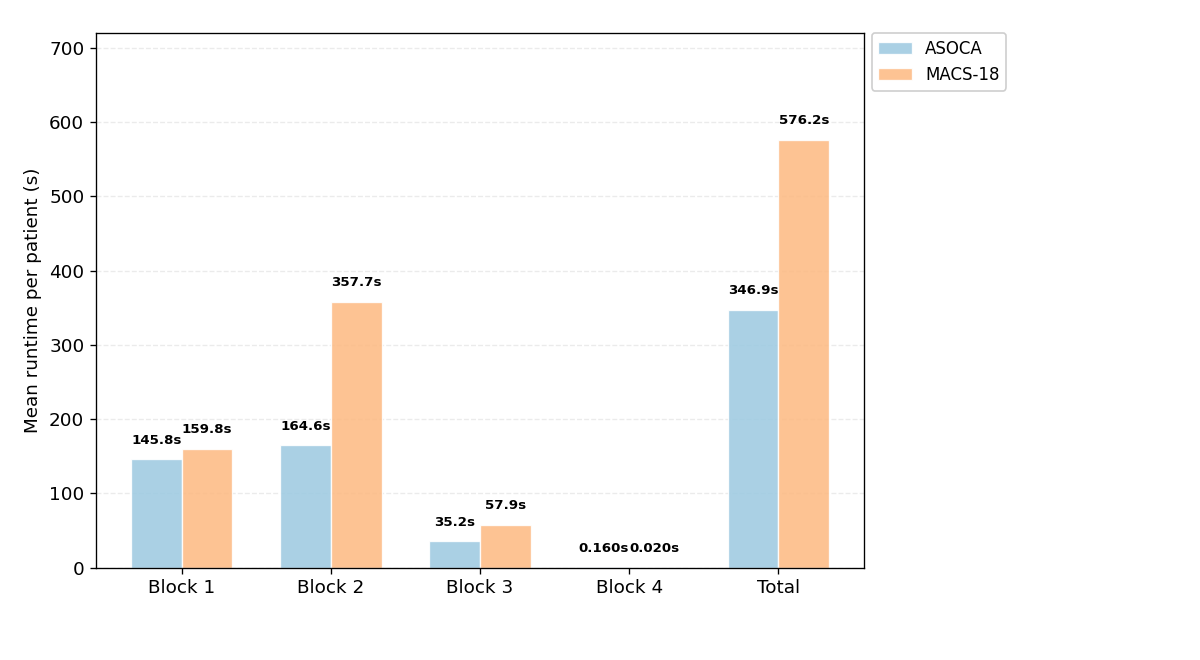

In [15]:
def _format_runtime_label(seconds: float) -> str:
    if seconds >= 10:
        return f"{seconds:.1f}s"
    if seconds >= 1:
        return f"{seconds:.2f}s"
    return f"{seconds:.3f}s"


def plot_runtimes_bars(
    runtimes_asoca: dict[str, float],
    runtimes_macs: dict[str, float],
    *,
    figsize: tuple[float, float] = (10.0, 5.5),
):
    x_labels = [RUNTIME_LABELS[k] for k in RUNTIME_KEYS]
    x = np.arange(len(RUNTIME_KEYS))
    bar_width = 0.34

    asoca_vals = [runtimes_asoca[k] for k in RUNTIME_KEYS]
    macs_vals = [runtimes_macs[k] for k in RUNTIME_KEYS]

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(
        x - bar_width / 2,
        asoca_vals,
        bar_width,
        label="ASOCA",
        color=COLOR_ASOCA,
        alpha=BAR_ALPHA,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.bar(
        x + bar_width / 2,
        macs_vals,
        bar_width,
        label="MACS-18",
        color=COLOR_MACS,
        alpha=BAR_ALPHA,
        edgecolor="white",
        linewidth=0.8,
    )

    y_max = max(asoca_vals + macs_vals)
    label_pad = max(8.0, 0.03 * y_max)

    for i, (va, vm) in enumerate(zip(asoca_vals, macs_vals)):
        ax.text(
            x[i] - bar_width / 2,
            va + label_pad,
            _format_runtime_label(va),
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold",
        )
        ax.text(
            x[i] + bar_width / 2,
            vm + label_pad,
            _format_runtime_label(vm),
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Mean runtime per patient (s)")
    ax.set_ylim(0, y_max * 1.22 + label_pad)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        framealpha=0.95,
    )
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    fig.subplots_adjust(left=0.08, right=0.72, top=0.95, bottom=0.14)
    return fig, ax


_preview_fig, _ = plot_runtimes_bars(RUNTIMES_ASOCA, RUNTIMES_MACS_18)
_buf = io.BytesIO()
_preview_fig.savefig(_buf, format="png", dpi=120)
_buf.seek(0)
display(Image(data=_buf.read()))
plt.close(_preview_fig)

## 4. Export figure and table

In [16]:
FIG_STEM = "fig_runtimes_asoca_vs_macs"
CSV_NAME = "runtimes_comparison.csv"

fig_path_nb = EXPORT_DIR / f"{FIG_STEM}.png"
fig_path_tex = THESIS_FIG_DIR / f"{FIG_STEM}.png"
csv_path = EXPORT_DIR / CSV_NAME

fig, _ = plot_runtimes_bars(RUNTIMES_ASOCA, RUNTIMES_MACS_18)
fig.savefig(fig_path_nb, dpi=300)
fig.savefig(fig_path_tex, dpi=300)
plt.close(fig)

df_runtimes.to_csv(csv_path, index=False)

print(f"Saved figure: {fig_path_nb}")
print(f"Saved figure: {fig_path_tex}")
print(f"Saved table : {csv_path}")

Saved figure: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\fig_runtimes_asoca_vs_macs.png
Saved figure: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\thesis\TFG_Latex2526\figures\fig_runtimes_asoca_vs_macs.png
Saved table : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\results visualizations\exports\runtimes_comparison.csv
